In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file=r'C:\Users\kkmal\venv\Customer_Churn_Prediction\notebooks\feature_transformed_telecom.csv'

df=pd.read_csv(file)

In [6]:
df[['StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'has_partner',
       'has_dependents', 'has_phoneservice']]

,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,has_partner,has_dependents,has_phoneservice
0,-1,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0,0
1,-1,One year,No,Mailed check,56.95,1889.50,No,0,0,1
2,-1,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,0,1
3,-1,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,0,0
4,-1,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,0,1
...,...,...,...,...,...,...,...,...,...,...
7038,1,One year,Yes,Mailed check,84.80,1990.50,No,1,1,1
7039,1,One year,Yes,Credit card (automatic),103.20,7362.90,No,1,1,1
7040,-1,Month-to-month,Yes,Electronic check,29.60,346.45,No,1,1,0
7041,-1,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1,0,1


In [7]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first',handle_unknown='ignore')
categorical_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']
encoded_data = ohe.fit_transform(df[categorical_cols]).toarray()
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1,)

df=df.drop(columns=['Unnamed: 0'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   tenure                                 7043 non-null   int64  
 3   OnlineSecurity                         7043 non-null   int64  
 4   OnlineBackup                           7043 non-null   int64  
 5   DeviceProtection                       7043 non-null   int64  
 6   TechSupport                            7043 non-null   int64  
 7   StreamingTV                            7043 non-null   int64  
 8   StreamingMovies                        7043 non-null   int64  
 9   MonthlyCharges                         7043 non-null   float64
 10  TotalCharges                           7043 non-null   float64
 11  Churn          

In [9]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Churn'])
y=df['Churn'].map({'No': 0, 'Yes': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['MonthlyCharges', 'TotalCharges']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [11]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5282, 27), (5282,), (1761, 27), (1761,))

In [12]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [13]:
import numpy as np
# Assuming y_train is a pandas Series or numpy array
# Calculate scale_pos_weight for XGBoost: (count of negative examples / count of positive examples)
ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

models_configuration = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "solver": ["liblinear", "lbfgs"]
        }
    },
    "Ridge Classifier": {
        "model": RidgeClassifier(class_weight="balanced"),
        "params": {
            "alpha": [0.1, 1.0, 10.0]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight="balanced"),
        "params": {
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight="balanced"),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20]
        }
    },
    "Gradient Boosting": {
        # GradientBoostingClassifier doesn't have class_weight, 
        # so we rely on subsampling or tuning, OR use HistGradientBoostingClassifier which does.
        "model": GradientBoostingClassifier(), 
        "params": {
            "learning_rate": [0.01, 0.1, 0.2],
            "n_estimators": [50, 100, 200]
        }
    },
    "XGBoost": {
        # scale_pos_weight controls the balance of positive/negative weights
        "model": XGBClassifier(eval_metric="logloss", scale_pos_weight=ratio),
        "params": {
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 7],
            "n_estimators": [50, 100, 200]
        }
    },
    "SVC": {
        "model": SVC(class_weight="balanced"),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "kernel": ["rbf", "linear"]
        }
    }
}

In [14]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to your TRAINING data (never the test data!)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Now, you can use your original loop from the previous answer, 
# just pass X_train_balanced and y_train_balanced into clf.fit()

from sklearn.model_selection import GridSearchCV


best_models = {}

for model_name, config in models_configuration.items():
    print(f"Tuning {model_name}...")

    clf = GridSearchCV(config["model"], config["params"], cv=5, scoring="roc_auc", n_jobs=-1)
    clf.fit(X_train_balanced, y_train_balanced)
    
    # Save the best model and score
    best_models[model_name] = {
        "best_model": clf.best_estimator_,
        "best_score": clf.best_score_,
        "best_params": clf.best_params_
    }
    
    print(f"Best Score: {clf.best_score_:.4f}\n")

Tuning Logistic Regression...
Best Score: 0.8440

Tuning Ridge Classifier...
Best Score: 0.8419

Tuning Decision Tree...
Best Score: 0.8157

Tuning Random Forest...
Best Score: 0.8413

Tuning Gradient Boosting...
Best Score: 0.8457

Tuning XGBoost...
Best Score: 0.8458

Tuning SVC...
Best Score: 0.8425



In [15]:
best_models['XGBoost']

{'best_model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=50, n_jobs=None,
               num_parallel_tree=None, ...),
 'best_score': np.float64(0.8458143320981766),
 'best_params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}}

In [23]:
ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

xgc=XGBClassifier(eval_metric="logloss", scale_pos_weight=ratio,learning_rate=0.1, max_depth=3, n_estimators=50)
xgc.fit(X_train_balanced, y_train_balanced)
y_pred_proba=xgc.predict_proba(X_test)
y_pred=xgc.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.61      0.74      1294
           1       0.45      0.88      0.60       467

    accuracy                           0.68      1761
   macro avg       0.69      0.75      0.67      1761
weighted avg       0.81      0.68      0.70      1761



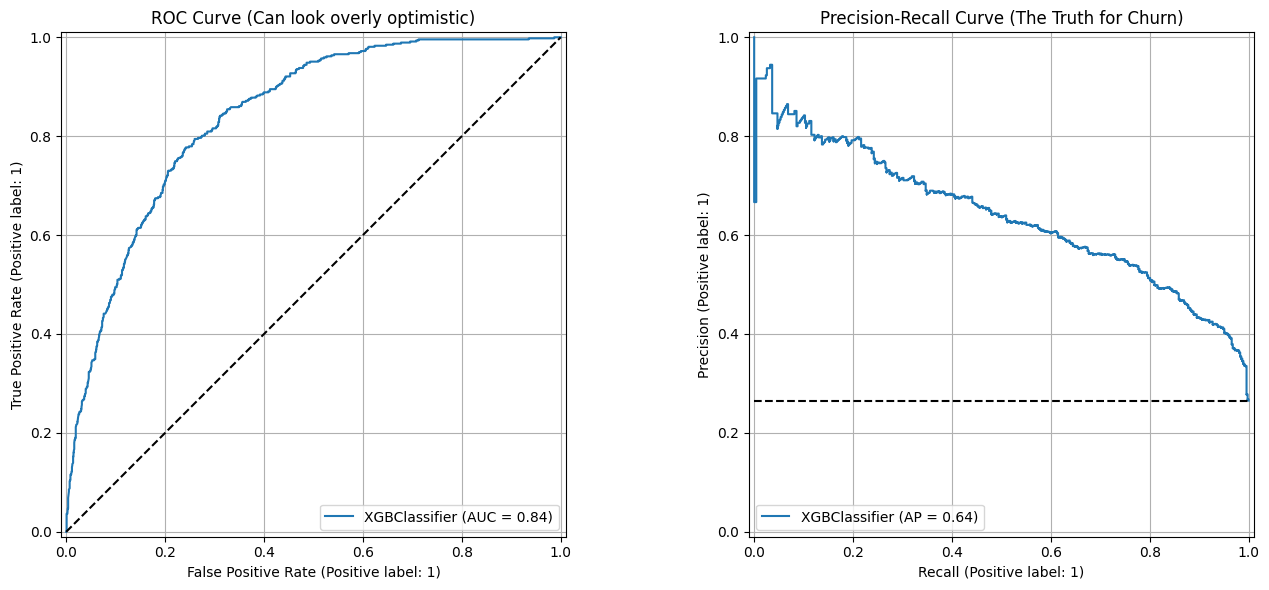

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Set up a 1x2 plotting area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Plot ROC Curve on the first axis
RocCurveDisplay.from_estimator(xgc, X_test, y_test, ax=ax1)
ax1.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
ax1.set_title('ROC Curve (Can look overly optimistic)')
ax1.grid(True)

# 2. Plot Precision-Recall Curve on the second axis
PrecisionRecallDisplay.from_estimator(xgc, X_test, y_test, ax=ax2)
# Baseline for PR curve is the percentage of positive cases (467 / 1761)
baseline = 467 / 1761
ax2.plot([0, 1], [baseline, baseline], 'k--', label=f'Random (AP = {baseline:.2f})')
ax2.set_title('Precision-Recall Curve (The Truth for Churn)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pickle

pickle.dump(xgc,open(r'C:\Users\kkmal\venv\Customer_Churn_Prediction\models\xgboost_model.pkl','wb'))
pickle.dump(scaler,open(r'C:\Users\kkmal\venv\Customer_Churn_Prediction\models\scaler.pkl','wb'))
pickle.dump(ohe,open(r'C:\Users\kkmal\venv\Customer_Churn_Prediction\models\ohe.pkl','wb'))